# Computer Vision Assignment 2 - B00150982


In [84]:
from __future__ import print_function

from tensorflow import keras
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import classification_report
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization 
from keras.optimizers import RMSprop,Adam 
import matplotlib.pyplot as plt
import numpy as np

In [85]:
batch_size = 12
num_classes = 3
epochs = 8
img_width = 128
img_height = 128
img_channels = 3
fit = True

train_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/train"
test_dir = "c:/Users/diana/Documents/CompVision/dataset/chest_xray/chest_xray/test"

## Dataset balance

In [87]:
bacterial_count = len(os.listdir(train_dir + "/BACTERIAL"))
normal_count = len(os.listdir(train_dir + "/NORMAL"))
viral_count = len(os.listdir(train_dir + "/VIRAL"))

print("Dataset distribution:")
print("BACTERIAL:", bacterial_count)
print("NORMAL:", normal_count)
print("VIRAL:", viral_count)

total = bacterial_count + normal_count + viral_count
print("Total images:", total)

Dataset distribution:
BACTERIAL: 2596
NORMAL: 1461
VIRAL: 1363
Total images: 5420


## Load dataset

In [89]:
train_ds,val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        seed=123,
        validation_split=0.2,
        subset='both',
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)
    
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        seed=None,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        labels='inferred',
        shuffle=True
)

class_names = train_ds.class_names
print('Class Names: ',class_names)
num_classes = len(class_names)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names:  ['BACTERIAL', 'NORMAL', 'VIRAL']


## Visualise images

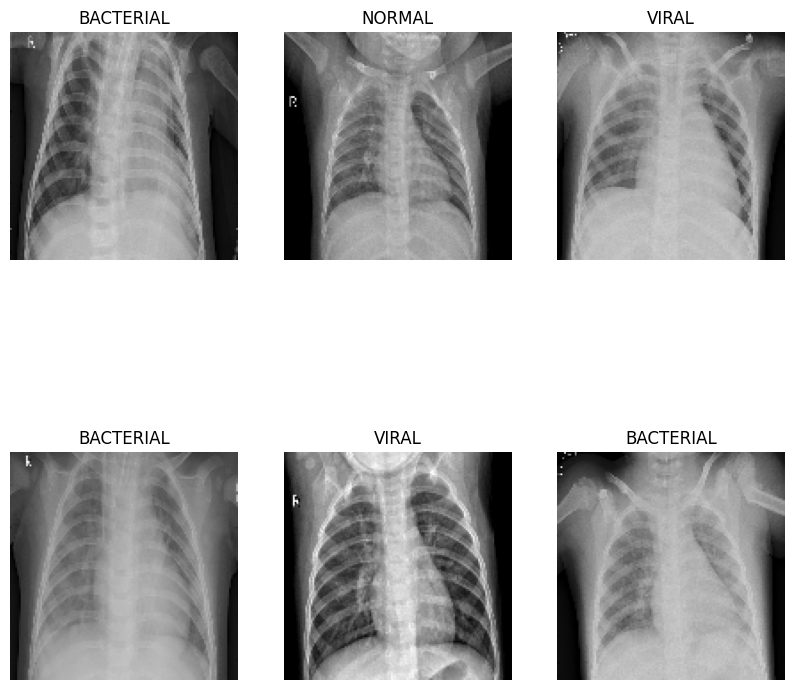

In [90]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

## Augmentation layer

In [91]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])

In [92]:
#create model
model = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation = 'relu', input_shape = (img_height,img_width, img_channels)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation = 'softmax')
])

In [93]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [94]:
save_callback = tf.keras.callbacks.ModelCheckpoint(
    "pneumonia.keras",
    save_best_only=True
)

## Train model

In [95]:
history = model.fit(
        train_ds,
        batch_size=batch_size,
        validation_data=val_ds,
        callbacks=[save_callback],
        epochs=epochs)

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.4924 - loss: 1.0294 - val_accuracy: 0.4903 - val_loss: 0.9956
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.5413 - loss: 0.9486 - val_accuracy: 0.5448 - val_loss: 0.9441
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.5570 - loss: 0.9238 - val_accuracy: 0.5577 - val_loss: 0.9247
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.5821 - loss: 0.8757 - val_accuracy: 0.5854 - val_loss: 0.9085
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.6338 - loss: 0.8155 - val_accuracy: 0.6270 - val_loss: 0.8443
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.6460 - loss: 0.8037 - val_accuracy: 0.6325 - val_loss: 0.8227
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.6541 - loss: 0.7835 - val_accuracy: 0.6574 - val_loss: 0.7681
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.6672 - loss: 0.7659 - val_accu

## Evaluate model

In [96]:
score = model.evaluate(test_ds, batch_size=batch_size)
print('Test accuracy:', score[1])

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6339 - loss: 0.7944
Test accuracy: 0.6338672637939453


In [97]:
# Generate predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
              precision    recall  f1-score   support

   BACTERIAL       0.45      0.47      0.46       184
      NORMAL       0.29      0.48      0.36       122
       VIRAL       0.37      0.12      0.18       131

    accuracy                           0.37       437
   macro avg       0.37      0.36      0.34       437
weighted avg       0.38      0.37      0.35       437



## Plot accuracy

C:\Users\diana\AppData\Local\Temp\ipykernel_29056\293871340.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


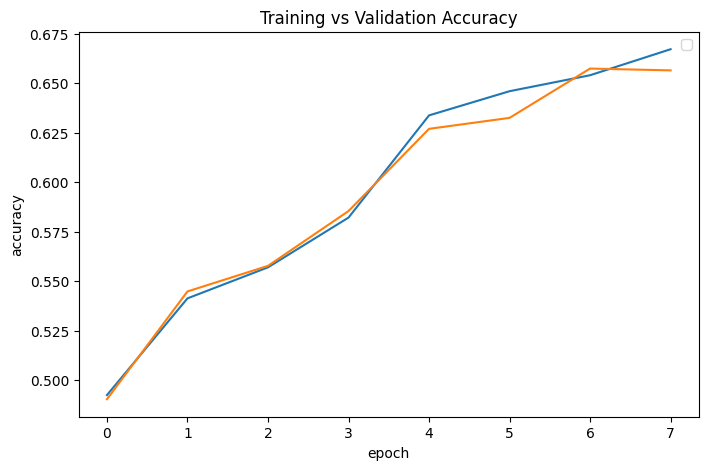

In [98]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

C:\Users\diana\AppData\Local\Temp\ipykernel_29056\2512735038.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


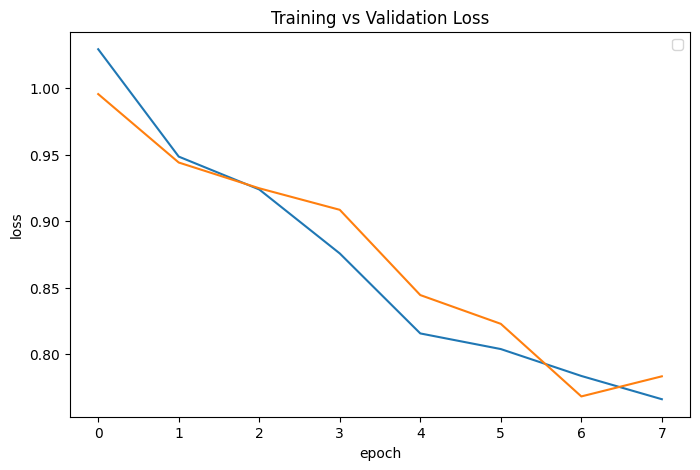

In [99]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

## Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


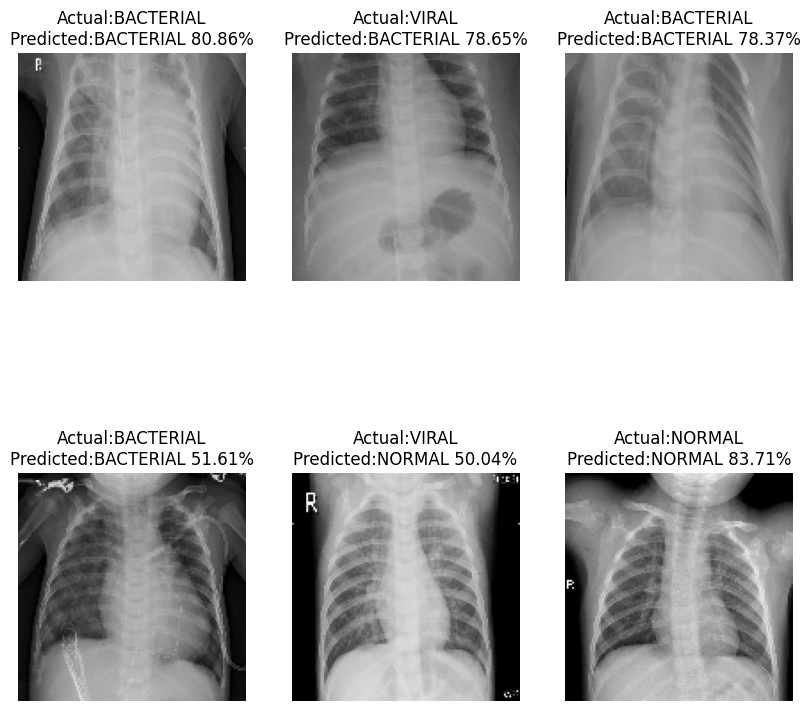

In [100]:
test_batch = test_ds.take(1)
plt.figure(figsize=(10, 10))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prediction = model.predict(tf.expand_dims(images[i].numpy(),0))#perform a prediction on this image
        plt.title('Actual:' + class_names[labels[i].numpy()]+ '\nPredicted:{} {:.2f}%'.format(class_names[np.argmax(prediction)], 100 * np.max(prediction)))
        plt.axis("off")
    plt.show()